In [1]:
!ls

04_iwamoto_2011_merge.csv  09_shi_2010_merge.csv  Untitled.ipynb


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('09_shi_2010_merge.csv')
df.head()

,patient_ID,cancer type,age,race,ER_status,response,PR_status,HER2_status,1007_s_at,1053_at,...,AFFX-r2-Hs28SrRNA-5_at,AFFX-r2-Hs28SrRNA-M_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,GSM505327,BC,57.0,white,p,RD,p,n,12.4440,8.3774,...,7.4678,9.3738,15.6236,15.2785,3.2915,3.6526,2.6412,1.2652,3.0690,2.0271
1,GSM505328,BC,69.0,asian,p,RD,p,n,12.2005,7.8592,...,9.6656,8.8500,15.3234,15.1286,3.3811,2.5880,4.4798,4.8098,3.1637,2.4758
2,GSM505329,BC,77.0,mixed,p,RD,n,p,12.6709,8.6762,...,7.6012,8.2567,15.4604,15.2674,3.1665,3.9743,5.2597,4.3815,2.8034,2.4669
3,GSM505330,BC,54.0,white,p,RD,n,n,11.6619,8.2557,...,7.6331,9.0089,15.5185,15.1655,4.0045,3.8503,5.9114,0.7882,3.1831,3.4820
4,GSM505331,BC,75.0,black,n,RD,n,n,11.8397,8.7971,...,8.0249,9.2004,15.3143,14.9506,3.0514,3.2946,5.1537,3.9179,3.1881,2.9769


In [4]:
df1 = df.copy()

In [5]:
df.set_index('patient_ID', inplace=True)
print(df.shape)

(278, 22290)


In [6]:
df['response'].unique()

array(['RD', 'pCR', nan], dtype=object)

In [7]:
df['response'].value_counts().plot.pie()
print(df['response'].value_counts())

RD     213
pCR     55
Name: response, dtype: int64


In [8]:
df['response'].isna().sum()

10

In [9]:
df.dtypes.value_counts(normalize=True)

float64    0.999731
object     0.000269
dtype: float64

In [10]:
(df.isna().sum(axis=0)/df.shape[0]).sort_values(ascending=False).head(10)

HER2_status        0.071942
race               0.035971
ER_status          0.035971
response           0.035971
PR_status          0.035971
age                0.003597
AFFX-TrpnX-M_at    0.000000
207912_s_at        0.000000
207902_at          0.000000
207904_s_at        0.000000
dtype: float64

In [106]:
# anlyse de fond
missing_rate = df.isna().sum(axis=0)/df.shape[0]

In [12]:
#deux types de donnees 
clinical_data = df[df.columns[missing_rate>0]]
gene_data = df[df.columns[missing_rate==0]]

In [13]:
#cancer type ne varie pas
gene_data.drop('cancer type', axis=1, inplace=True)

/home/ouahbi/anaconda3/lib/python3.7/site-packages/pandas/core/frame.py:3940: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  errors=errors)


In [57]:
#from object to categ
for col in clinical_data:
    if clinical_data[col].dtypes== 'object':
        clinical_data[col]=clinical_data[col].astype('category')

/home/ouahbi/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  after removing the cwd from sys.path.


In [58]:
clinical_data.dtypes=='object'

age            False
race           False
ER_status      False
response       False
PR_status      False
HER2_status    False
dtype: bool

In [59]:
gene_data.dtypes.unique()

array([dtype('float64')], dtype=object)

In [60]:
#do there is two types of var : category and float

In [61]:
for clin in clinical_data.select_dtypes('category'):
    print(clin,'=============>',clinical_data[clin].unique())

race =============> [white, asian, mixed, black, hispanic]
Categories (5, object): [white, asian, mixed, black, hispanic]
ER_status =============> [p, n]
Categories (2, object): [p, n]
response =============> [RD, pCR]
Categories (2, object): [RD, pCR]
PR_status =============> [p, n]
Categories (2, object): [p, n]
HER2_status =============> [n, p]
Categories (2, object): [n, p]


In [74]:
dico = {'p':0, 'n':1}
clinical_data['race'] = clinical_data['race'].map({'white':0, 'asian':1, 'mixed':2, 'black':3, 'hispanic':4})
clinical_data['ER_status'] = clinical_data['ER_status'].map(dico)
clinical_data['response'] = clinical_data['response'].map({'RD':0, 'pCR':1})
clinical_data['PR_status'] = clinical_data['PR_status'].map(dico)
clinical_data['HER2_status'] = clinical_data['HER2_status'].map(dico)

/home/ouahbi/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  
/home/ouahbi/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  This is separate from the ipykernel package so we can avoid doing imports until
/home/ouahbi/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inste

In [80]:
clinical_data.dtypes

age            float64
race             int64
ER_status        int64
response         int64
PR_status        int64
HER2_status      int64
dtype: object

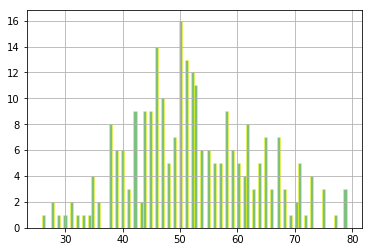

In [62]:
import matplotlib.pyplot as plt
plt.hist(x = clinical_data['age'],bins=100,lw=1, ec="yellow", fc="green", alpha=0.5)
plt.grid(True)

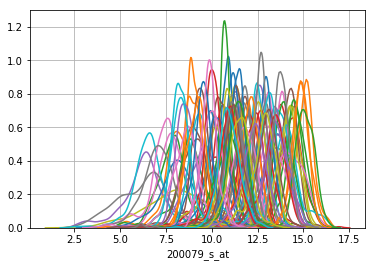

In [63]:
import seaborn as sns
for col in gene_data.iloc[:,:100]:
    sns.distplot(gene_data[col], hist=False)
    plt.grid(True)

In [64]:
# distributiopn des genes asymetric

In [65]:
clinical_data.dropna(inplace=True)

/home/ouahbi/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  """Entry point for launching an IPython kernel.


In [86]:
NR_df = clinical_data[clinical_data['response'] == 0]
R_df = clinical_data[clinical_data['response'] == 1]

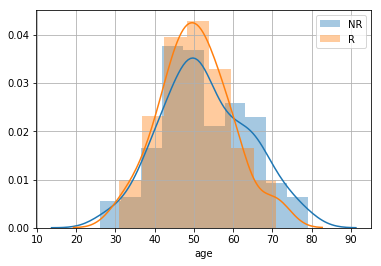

In [90]:
#voir la distribution d'age en fonction de la target
for col in clinical_data.select_dtypes('float'):
    plt.figure()
    sns.distplot(NR_df[col], label='NR')
    sns.distplot(R_df[col], label='R')
    plt.legend()
    plt.grid(True)

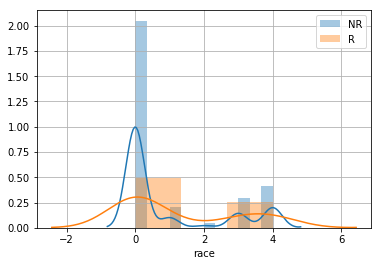

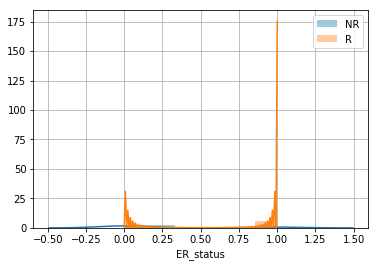

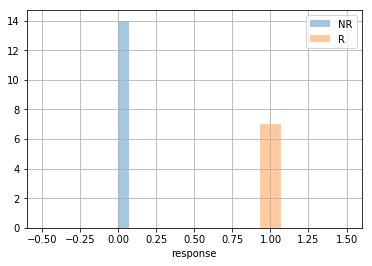

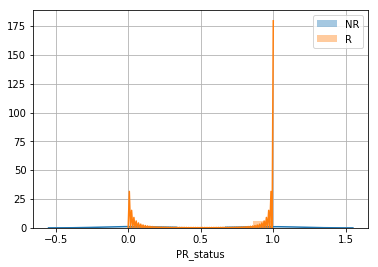

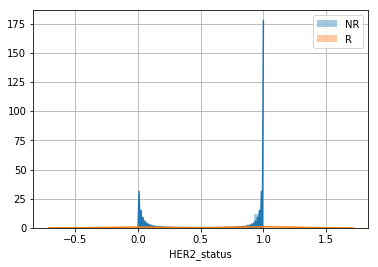

In [89]:
for col in clinical_data.select_dtypes('int'):
    plt.figure()
    sns.distplot(NR_df[col], label='NR')
    sns.distplot(R_df[col], label='R')
    plt.legend()
    plt.grid(True)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48]),
 <a list of 49 Text xticklabel objects>)

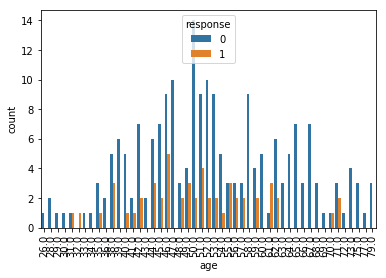

In [91]:
%matplotlib inline
#distribution mais en countplot ====> plus en detaille
sns.countplot(x='age', hue='response', data=clinical_data)
plt.xticks(rotation=90)

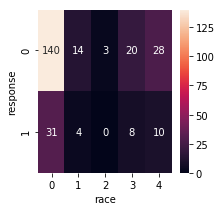

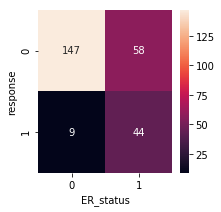

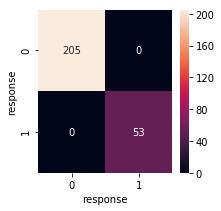

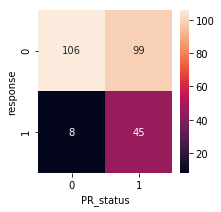

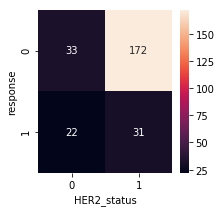

In [93]:
for col in clinical_data.select_dtypes('int'):
    plt.figure(figsize=(3,3))
    sns.heatmap(pd.crosstab(clinical_data['response'], clinical_data[col]), annot=True, fmt="d")

pr status et er status pourrait etre interessante plus la suite ====> tres cooreler a la target 

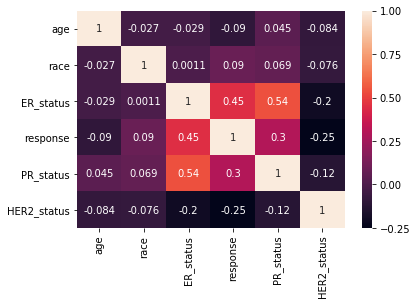

In [97]:
# relation entre chaque deux variable des clinical data
sns.heatmap(clinical_data.corr(), annot=True)

- corr fortement positive = PR_STAT AVEC ER_STAT 
- corr target / var : 
    - response avec her2 et age ===>  fortement correler negativement
    - response avec er et pr_status ==>  fortement correler positivement 


<Figure size 432x288 with 0 Axes>

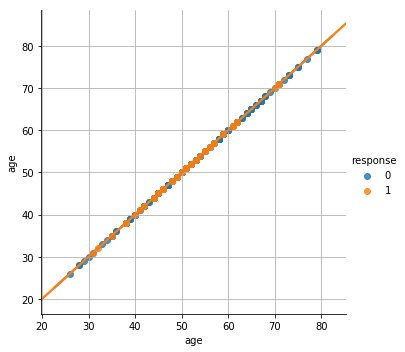

<Figure size 432x288 with 0 Axes>

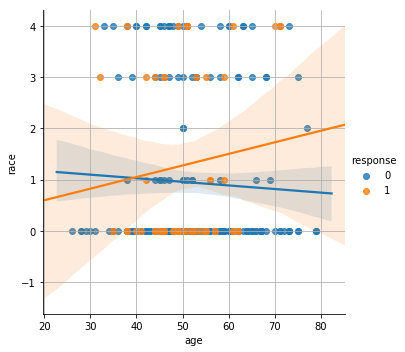

<Figure size 432x288 with 0 Axes>

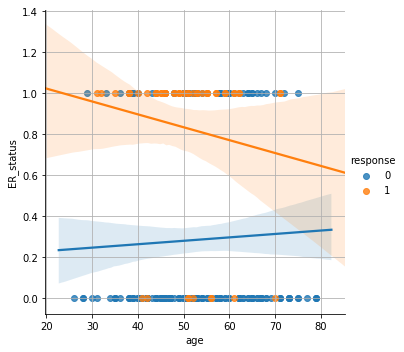

<Figure size 432x288 with 0 Axes>

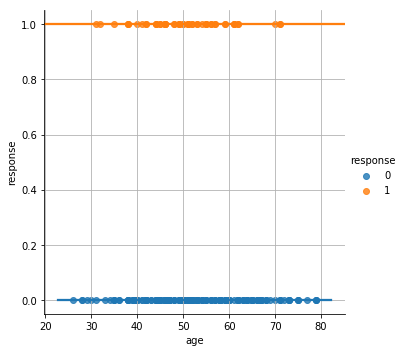

<Figure size 432x288 with 0 Axes>

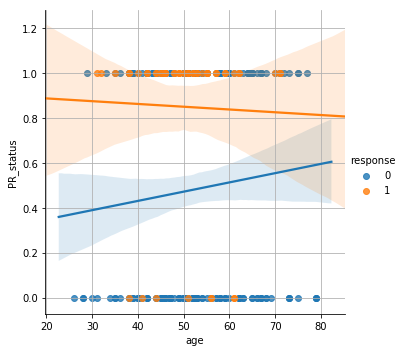

<Figure size 432x288 with 0 Axes>

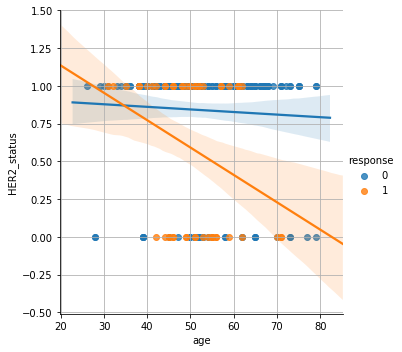

In [102]:
#relation age et chque variable 
for col in clinical_data:
    plt.figure()
    sns.lmplot(x='age', y=col, hue='response', data=clinical_data)
    plt.grid(True)

- nos droite ne se supperpose jamais ====> pas de similariter de notre target (cad meme age pour les repondeur et non repondeurs par exemple) ==> chose qui est bien
- il ya des outlies partout dans toutes nos variables 


In [103]:
#analyse des nan

In [111]:
missing_rate.head(8)

cancer type    0.000000
age            0.003597
race           0.035971
ER_status      0.035971
response       0.035971
PR_status      0.035971
HER2_status    0.071942
1007_s_at      0.000000
dtype: float64

In [114]:
df['response'].value_counts(normalize=True)

RD     0.794776
pCR    0.205224
Name: response, dtype: float64

In [118]:
#on a garder un peut pres les meme proportion de notre target par rapport a avant de supprimer les na ==> bien
df.dropna()['response'].value_counts(normalize=True)

RD     0.794574
pCR    0.205426
Name: response, dtype: float64

In [119]:
df.dropna(inplace=True)

In [120]:
df.shape

(258, 22290)

In [122]:
#test d'hypothese
from scipy.stats import ttest_ind


In [125]:
clinical_data['response'].value_counts()

0    205
1     53
Name: response, dtype: int64

In [132]:
balanced_NR = NR_df.sample(R_df.shape[0])

In [134]:
print(balanced_NR.shape, R_df.shape)

(53, 6) (53, 6)


In [136]:
#une fois on a equilibrer les shape ====> on passe au test
#on verifie si la difference de chaque variable entre nos repondeurs et nos non repondeurs est significativement differente (0 ) ou non (H0 REJETER)
def t_test(col):
    alpha = 0.02
    stat, p=ttest_ind(balanced_NR[col], R_df[col])
    if p<alpha:
        return 'H0 REJETER'
    else:
        return 0

In [141]:
for var, col in zip(clinical_data.columns, clinical_data):
    print(var,'======>',t_test(col))

age ======> 0
race ======> 0
ER_status ======> H0 REJETER
response ======> H0 REJETER
PR_status ======> H0 REJETER
HER2_status ======> H0 REJETER


- FINNALEMENT NOS DEUX VARIABLES AGE ET RACE SONT INTERESSANTE POUR LA PREDICTION DE LA REPONSE